# Gaussian Mixture Model - GMM




## GMMs

GMMs are a probabilistic model for representing normally distributed subpopulations within an overall population. They assume that the data is generated from a mixture of several Gaussian distributions with unknown parameters. The goal is to estimate the parameters of these Gaussian distributions (mean, covariance) and the mixing coefficients.

* Implementing the GMM logic using the class structure below. The GMM class should be able to fit to data using the EM algorithm.
* Visualizing the performance of your GMM implementation on synthetic data, i.e., generate data from known Gaussian distributions and show how well your GMM can recover the original parameters.

In [ ]:
import numpy as np
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class GMM:
    """
    Gaussian Mixture Model implementation using the EM algorithm.
    Supports 'full' or 'diag' covariance, diagonal/off-diagonal shrinkage regularization,
    and numerically stable responsibilities via log-sum-exp.
    """
    def __init__(self,
                 n_components=3,
                 covariance_type='full',          # 'full' or 'diag'
                 max_iters=200,
                 tol=1e-4,                        # convergence on log-likelihood improvement
                 reg_covar=1e-6,                  # diagonal loading
                 random_state=None,
                 init_params='random',            # 'random' or 'kmeans-like' (random data points)
                 enforce_diagonal=False,          # force diagonal covariances (uncorrelated assumption)
                 offdiag_shrinkage=0.0            # 0=no shrink, 1=full diag shrinkage
                 ):
        self.n_components = n_components
        self.covariance_type = covariance_type
        self.max_iters = max_iters
        self.tol = tol
        self.reg_covar = reg_covar
        self.random_state = random_state
        self.init_params = init_params
        self.enforce_diagonal = enforce_diagonal
        self.offdiag_shrinkage = float(np.clip(offdiag_shrinkage, 0.0, 1.0))

        # Learned parameters
        self.weights_ = None        # (K,)
        self.means_ = None          # (K, D)
        self.covariances_ = None    # (K, D, D) or (K, D) if diag

        # Diagnostics
        self.log_likelihood_ = None
        self.log_likelihood_history_ = []

        if self.random_state is not None:
            np.random.seed(self.random_state)

    def _initialize_parameters(self, X):
        N, D = X.shape
        K = self.n_components

        # Initialize weights uniformly
        self.weights_ = np.full(K, 1.0 / K, dtype=float)

        # Initialize means: select random data points
        idx = np.random.choice(N, K, replace=False)
        self.means_ = X[idx].copy()

        # Initialize covariances
        if self.covariance_type == 'full':
            # common empirical covariance to start
            emp_cov = np.cov(X, rowvar=False) + self.reg_covar * np.eye(D)
            self.covariances_ = np.stack([emp_cov.copy() for _ in range(K)], axis=0)
        elif self.covariance_type == 'diag':
            var = X.var(axis=0) + self.reg_covar
            self.covariances_ = np.stack([var.copy() for _ in range(K)], axis=0)
        else:
            raise ValueError("Unsupported covariance_type: use 'full' or 'diag'")

    def _log_gaussian(self, X, mean, cov):
        """
        Compute log N(X | mean, cov) for all rows in X.
        Handles full or diagonal covariances with numeric stability.
        """
        D = X.shape[1]
        diff = X - mean
        if cov.ndim == 1:
            # Diagonal covariance given as vector
            prec = 1.0 / cov
            log_det = np.sum(np.log(cov))
            quad = np.sum((diff**2) * prec, axis=1)
        else:
            # Full covariance matrix
            # Use Cholesky for numerics: log det and solve
            L = np.linalg.cholesky(cov)
            # Solve L y = diff^T  => y = L^{-1} diff^T
            y = np.linalg.solve(L, diff.T)
            quad = np.sum(y**2, axis=0)
            log_det = 2.0 * np.sum(np.log(np.diag(L)))
        return -0.5 * (D * np.log(2.0 * np.pi) + log_det + quad)

    def _estimate_log_prob(self, X):
        """
        Matrix of log p(x_i | component k), shape (N, K).
        """
        N, D = X.shape
        K = self.n_components
        log_prob = np.empty((N, K), dtype=float)
        for k in range(K):
            if self.covariance_type == 'full':
                log_prob[:, k] = self._log_gaussian(X, self.means_[k], self.covariances_[k])
            else:
                log_prob[:, k] = self._log_gaussian(X, self.means_[k], self.covariances_[k])
        return log_prob

    def _e_step(self, X):
        """
        Expectation step: compute responsibilities and log-likelihood.
        Returns:
          responsibilities: (N, K)
          log_likelihood: float
        """
        log_prob = self._estimate_log_prob(X)  # (N, K)
        # Add log-weights
        log_prob += np.log(self.weights_[None, :])

        # log-sum-exp across components for normalization
        max_log = np.max(log_prob, axis=1, keepdims=True)
        stabilized = log_prob - max_log
        sum_exp = np.exp(stabilized).sum(axis=1, keepdims=True)
        log_sum_exp = np.log(sum_exp) + max_log

        # Responsibilities
        log_resp = log_prob - log_sum_exp
        responsibilities = np.exp(log_resp)

        # Total log-likelihood
        log_likelihood = np.sum(log_sum_exp)
        return responsibilities, float(log_likelihood)

    def _regularize_cov(self, cov):
        """
        Apply diagonal loading and optional shrinkage toward diagonal,
        and optionally enforce diagonal structure exactly.
        """
        if cov.ndim == 1:
            # Diagonal vector
            cov = np.maximum(cov, self.reg_covar)
            return cov
        # Full matrix
        D = cov.shape[0]
        # Diagonal loading
        cov = cov + self.reg_covar * np.eye(D)
        if self.offdiag_shrinkage > 0.0:
            diag_cov = np.diag(np.diag(cov))
            cov = (1.0 - self.offdiag_shrinkage) * cov + self.offdiag_shrinkage * diag_cov
        if self.enforce_diagonal or self.covariance_type == 'diag':
            return np.diag(np.clip(np.diag(cov), self.reg_covar, np.inf))
        return cov

    def _m_step(self, X, responsibilities):
        """
        Maximization step: update weights, means, covariances.
        """
        N, D = X.shape
        K = self.n_components

        Nk = responsibilities.sum(axis=0) + 1e-16  # avoid divide-by-zero
        self.weights_ = (Nk / N).astype(float)

        # Means
        self.means_ = (responsibilities.T @ X) / Nk[:, None]

        # Covariances
        if self.covariance_type == 'diag':
            covs = np.empty((K, D), dtype=float)
            for k in range(K):
                diff = X - self.means_[k]
                w = responsibilities[:, k][:, None]
                var = (w * (diff**2)).sum(axis=0) / Nk[k]
                covs[k] = self._regularize_cov(var)
            self.covariances_ = covs
        elif self.covariance_type == 'full':
            covs = np.empty((K, D, D), dtype=float)
            for k in range(K):
                diff = X - self.means_[k]
                w = responsibilities[:, k]
                # Weighted covariance
                cov_k = (diff * w[:, None]).T @ diff / Nk[k]
                covs[k] = self._regularize_cov(cov_k)
            self.covariances_ = covs
        else:
            raise ValueError("Unsupported covariance_type: use 'full' or 'diag'")

    def fit(self, X):
        """
        Fit GMM to data using the EM algorithm.
        """
        X = np.asarray(X, dtype=float)
        if X.ndim != 2:
            raise ValueError("X must be 2D array (N, D)")
        self._initialize_parameters(X)
        self.log_likelihood_history_ = []

        prev_ll = -np.inf
        for _ in range(self.max_iters):
            resp, ll = self._e_step(X)
            self._m_step(X, resp)
            self.log_likelihood_history_.append(ll)
            if np.abs(ll - prev_ll) <= self.tol:
                break
            prev_ll = ll

        # Final E-step for reporting
        _, final_ll = self._e_step(X)
        self.log_likelihood_ = final_ll
        return self

    def predict(self, X):
        """
        Predict the most likely component label for each sample.
        """
        X = np.asarray(X, dtype=float)
        log_prob = self._estimate_log_prob(X) + np.log(self.weights_[None, :])
        return np.argmax(log_prob, axis=1)

    def predict_proba(self, X):
        """
        Return responsibilities p(z=k | x) for each sample.
        """
        X = np.asarray(X, dtype=float)
        resp, _ = self._e_step(X)
        return resp


Final log-likelihood: -3226.502966190375
Weights: [0.256 0.333 0.411]
Means:
 [[-3.979  4.089]
 [ 3.988  3.882]
 [-0.037 -0.04 ]]
First covariance matrix:
 [[0.617 0.055]
 [0.055 0.608]]


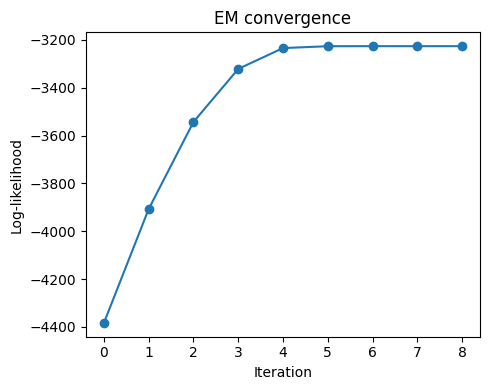

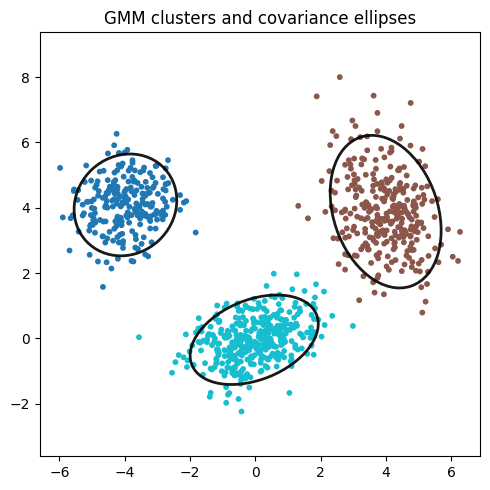

True comp 0 matched to learned 2: mean L2 err=0.055, cov Frobenius err=0.101
True comp 1 matched to learned 1: mean L2 err=0.118, cov Frobenius err=0.195
True comp 2 matched to learned 0: mean L2 err=0.091, cov Frobenius err=0.080


In [ ]:
# --- Generate synthetic 2D mixture (3 components) ---
np.random.seed(7)
true_means = np.array([[0, 0],
                       [4, 4],
                       [-4, 4]], dtype=float)
true_covs = np.array([
    [[1.0, 0.3],
     [0.3, 0.5]],
    [[0.8, -0.2],
     [-0.2, 1.2]],
    [[0.6, 0.0],
     [0.0, 0.6]]
], dtype=float)
true_weights = np.array([0.4, 0.35, 0.25], dtype=float)

N = 900
z = np.random.choice(len(true_weights), size=N, p=true_weights)
X = np.zeros((N, 2))
for k in range(len(true_weights)):
    nk = np.sum(z == k)
    X[z == k] = np.random.multivariate_normal(true_means[k], true_covs[k], size=nk)

# --- Fit GMM ---
gmm = GMM(n_components=3,
          covariance_type='full',
          max_iters=300,
          tol=1e-4,
          reg_covar=1e-6,
          random_state=42,
          init_params='random',
          enforce_diagonal=False,
          offdiag_shrinkage=0.0).fit(X)

print("Final log-likelihood:", gmm.log_likelihood_)
print("Weights:", np.round(gmm.weights_, 3))
print("Means:\n", np.round(gmm.means_, 3))
print("First covariance matrix:\n", np.round(gmm.covariances_[0], 3))

# --- Plot log-likelihood over iterations ---
plt.figure(figsize=(5,4))
plt.plot(gmm.log_likelihood_history_, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
plt.title("EM convergence")
plt.tight_layout()
plt.show()

# --- Helper: plot Gaussian ellipses ---
def plot_gaussian_ellipses(ax, mean, cov, color='k', nsig=2.0, lw=2):
    # Eigen-decomposition for ellipse axes
    vals, vecs = np.linalg.eigh(cov)
    vals = np.maximum(vals, 1e-12)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(vecs[1,0], vecs[0,0]))
    width, height = 2*nsig*np.sqrt(vals)
    from matplotlib.patches import Ellipse
    e = Ellipse(xy=mean, width=width, height=height, angle=theta,
                edgecolor=color, facecolor='none', lw=lw, alpha=0.9)
    ax.add_patch(e)

# --- Scatter + learned ellipses ---
plt.figure(figsize=(5,5))
labels = gmm.predict(X)
plt.scatter(X[:,0], X[:,1], c=labels, s=10, cmap='tab10')
for k in range(gmm.n_components):
    plot_gaussian_ellipses(plt.gca(), gmm.means_[k], gmm.covariances_[k], color='black', nsig=2.0, lw=2)
plt.title("GMM clusters and covariance ellipses")
plt.axis('equal')
plt.tight_layout()
plt.show()

# --- Parameter recovery summary (greedy match by nearest mean) ---
from scipy.spatial.distance import cdist
D = cdist(true_means, gmm.means_)
match = D.argmin(axis=1)  # greedy (for simplicity)
for i, k in enumerate(match):
    mean_err = np.linalg.norm(true_means[i] - gmm.means_[k])
    cov_err = np.linalg.norm(true_covs[i] - gmm.covariances_[k])
    print(f"True comp {i} matched to learned {k}: mean L2 err={mean_err:.3f}, cov Frobenius err={cov_err:.3f}")


## Regularizing the GMM (BONUS)

* Implementing regularization techniques for the covariance matrices to towards the assumption of uncorrelated input features. Extending the existing `GMM` class above.

In [ ]:
#stronger regularization and diagonal bias
gmm_reg = GMM(n_components=3,
              covariance_type='full',
              max_iters=300,
              tol=1e-4,
              reg_covar=1e-3,          # stronger diagonal loading
              random_state=0,
              enforce_diagonal=False,   # keep full but shrink off-diagonals
              offdiag_shrinkage=0.5     # halfway toward diagonal
              ).fit(X)

print("With shrinkage: weights:", np.round(gmm_reg.weights_, 3))
print("With shrinkage: first covariance:\n", np.round(gmm_reg.covariances_[0], 3))

# Strictly uncorrelated assumption (pure diagonal covariances)
gmm_diag = GMM(n_components=3,
               covariance_type='diag',
               max_iters=300,
               tol=1e-4,
               reg_covar=1e-4,
               random_state=0,
               enforce_diagonal=True     # redundant with covariance_type='diag', kept for clarity
               ).fit(X)

print("Diagonal-cov: first covariance vector:\n", np.round(gmm_diag.covariances_[0], 3))


With shrinkage: weights: [0.256 0.334 0.411]
With shrinkage: first covariance:
 [[0.618 0.028]
 [0.028 0.609]]
Diagonal-cov: first covariance vector:
 [0.617 0.608]
